## Predicting Income >$50K Using 1994 UCI Adult Census

### **Summary**
We applied a logisitic regression model on the 1994 UCI Adult Census dataset to predict whether an individual earns `<=$50k` or `>$50k` a year. The model achived an accuracy of ~80.13%. One of the patterns we found from our exploratory data analysis was that education and income seem to be positively correlated. As the education level of an individual increases, their income seems to increase. Another important correlation was between marital status and income, i.e. married individuals were more likely to earn `>$50k` when compared to non-married individuals. The findings from this analysis can be used to influence education and other policies. Due to the strong performance of this model it can also be seen as a template to be used in other economic research. 

### **Introduction**
Income is influenced by a mix of personal and labor-market factors such as education, occupation, and hours worked. Predicting whether someone earns above a given threshold is a common “classification” problem in data science and also raises practical questions about how demographic and job characteristics relate to earnings outcomes.

This project uses the UCI Adult (Census Income) dataset to build and evaluate a model that predicts whether an individual’s annual income is `>$50K` using demographic and work-related features (e.g., age, education, occupation, hours worked per week). The dataset contains *48,842* observations and *14* input features (6 quantitative and 8 categorical), with the target variable indicating whether income exceeds $50K.  UCI also notes that records were selected using the following conditions:
- Age > 16  
- Adjusted gross income (AGI) > 100  
- Final weight (AFNLWGT) > 1  
- Hours worked per week (HRSWK) > 0 

### **Methods & Results**

### Data Wrangling Summary
Since the original data does not include column names, descriptive variable names were manually assigned based on the dataset documentation. The data was then cleaned by removing observations containing missing or undefined values (represented by `"?"`) in key categorical variables such as workclass, occupation, and native country, as well as filtering out individuals who had never worked. Several categorical variables were transformed into binary indicator variables to make the dataset more suitable for quantitative analysis and modeling, including indicators for marital status, sex, and race categories. The target variable, income, was converted into a binary numeric outcome where 1 represents individuals earning more than $50K annually and 0 otherwise. Finally, redundant or highly categorical variables that were no longer needed after encoding were removed, resulting in a cleaned, analysis-ready data frame composed primarily of numeric predictors and selected categorical information.

### Analysis Summary
We then conducted some exploratory data analysis, including a visualization of class distribution between > and <$50,000 income generating adults, as well as a correlation matrix to help inform variable selection. Once we isolated our variables of interest, we fit a simple logistic regression to conduct our classification experiment. 

In [34]:
library(dplyr)

url <- "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

download.file(url, "data/raw/adult_raw.csv", mode = "wb")

url_2 <- "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.names"
download.file(url_2, "data/raw/adult_names_raw.csv", mode = "wb")



In [35]:
adult_raw <- read.csv("data/raw/adult_raw.csv", 
                        header = FALSE,
                        na.strings = "?")
colnames(adult_raw) <- c("age", "workclass", "fnlwgt", "education", "education_num",
                        "marital_status", "occupation", "relationship", "race", "sex",
                        "capital_gain", "capital_loss", "hours_per_week", "native_country", "income")
head(adult_raw)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
,<int>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>
1,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
2,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
3,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
4,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
5,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
6,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


In [36]:
unique(adult_raw$income)

[1] " <=50K" " >50K"

In [37]:
#Note: there are some missing values from workclass, occupation
# unique(adult_raw$marital_status)
adult_processed <- adult_raw |> filter(workclass != " Never-worked" & #filtering those that never worked as its all below 50k
                                        workclass != " ?" &  #removing missing values
                                        occupation != " ?" &
                                        native_country != " ?") |>
                                mutate(married = ifelse(marital_status != " Widowed" & 
                                                        marital_status != " Never-married", 
                                                        1, 0))|>
                                mutate(male = ifelse(sex == " Male", 
                                                        1, 0))|>
                                mutate(race_white = ifelse(race == " White", 
                                                        1, 0))|>
                                mutate(race_asian_pac_islander = ifelse(race == " Asian-Pac-Islander", 
                                                        1, 0))|>
                                mutate(race_amer_indian_eskimo = ifelse(race == " Amer-Indian-Eskimo", 
                                                        1, 0))|>
                                mutate(race_black = ifelse(race == " Black", 
                                                        1, 0))|>
                                mutate(race_other = ifelse(race == " Other", 
                                                        1, 0))|>
                                mutate(income = ifelse(income == " >50K", 
                                                        1, 0))|>
                                select(-education, -fnlwgt, -marital_status, 
                                        -workclass, -occupation, -relationship,
                                        -race, -sex)
head(adult_processed)

#explanation on variables
#income = 1 if over 50k
#married = 1 if not devorced or never married (widowed counts as married)

write.csv(adult_processed, "data/processed/adult_processed.csv", row.names = FALSE)

,age,education_num,capital_gain,capital_loss,hours_per_week,native_country,income,married,male,race_white,race_asian_pac_islander,race_amer_indian_eskimo,race_black,race_other
,<int>,<int>,<int>,<int>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,39,13,2174,0,40,United-States,0,0,1,1,0,0,0,0
2,50,13,0,0,13,United-States,0,1,1,1,0,0,0,0
3,38,9,0,0,40,United-States,0,1,1,1,0,0,0,0
4,53,7,0,0,40,United-States,0,1,1,0,0,0,1,0
5,28,13,0,0,40,Cuba,0,1,0,0,0,0,1,0
6,37,14,0,0,40,United-States,0,1,0,1,0,0,0,0


In [38]:
class_counts <- adult_processed |>
  count(income) |>
  mutate(prop = n / sum(n))

class_counts

income,n,prop
<dbl>,<int>,<dbl>
0,22654,0.7510775
1,7508,0.2489225


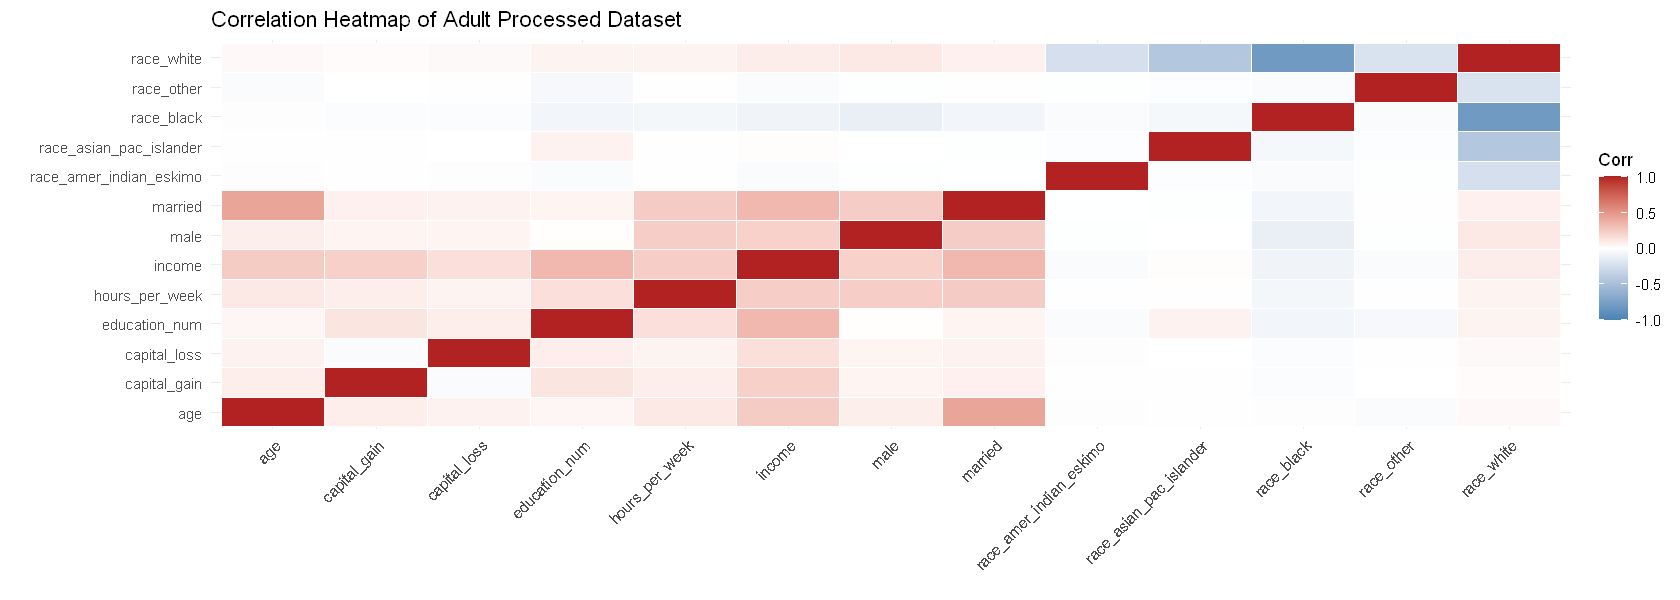

In [39]:
# ---- Correlation heatmap ----
library(dplyr)
library(ggplot2)
library(tidyr)

# 1) Select numeric variables only
num_df <- adult_processed |>
  select(where(is.numeric))

# 2) Compute correlation matrix
cor_mat <- cor(num_df, use = "complete.obs")

# 3) Convert matrix to long format for plotting
cor_long <- as.data.frame(cor_mat) |>
  tibble::rownames_to_column("Var1") |>
  pivot_longer(-Var1, names_to = "Var2", values_to = "Correlation")

# 4) Plot heatmap
ggplot(cor_long, aes(x = Var1, y = Var2, fill = Correlation)) +
  geom_tile(color = "white") +
  scale_fill_gradient2(
    low = "steelblue",
    mid = "white",
    high = "firebrick",
    midpoint = 0,
    limits = c(-1, 1)
  ) +
  theme_minimal() +
  labs(
    title = "Correlation Heatmap of Adult Processed Dataset",
    x = "",
    y = "",
    fill = "Corr"
  ) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

*Figure 1. Correlation heatmap of the Adult processed dataset.*

We can see there is a skew towards adults that generate an income of <$50,000 in the data set. This means a simple dummy classifier should do quite well on the training set, though likely not out of sample.

Further using the correlation matrix, we can see that the education_num and married variables hold the strongest associations with the response variable income, which we will use to help inform which variables to include in our classification task. We can also see that these two input variables are not highly correlated, which is another positive.

In [40]:
# Simple logistic regression classification

# fit model
model <- glm(income ~ education_num + married,
             data = adult_processed,
             family = binomial())

# predict probabilities
pred_prob <- predict(model, type = "response")

# convert to class predictions (0/1)
pred_class <- ifelse(pred_prob > 0.5, 1, 0)

# simplest accuracy score
accuracy <- mean(pred_class == adult_processed$income)

accuracy

[1] 0.8012731

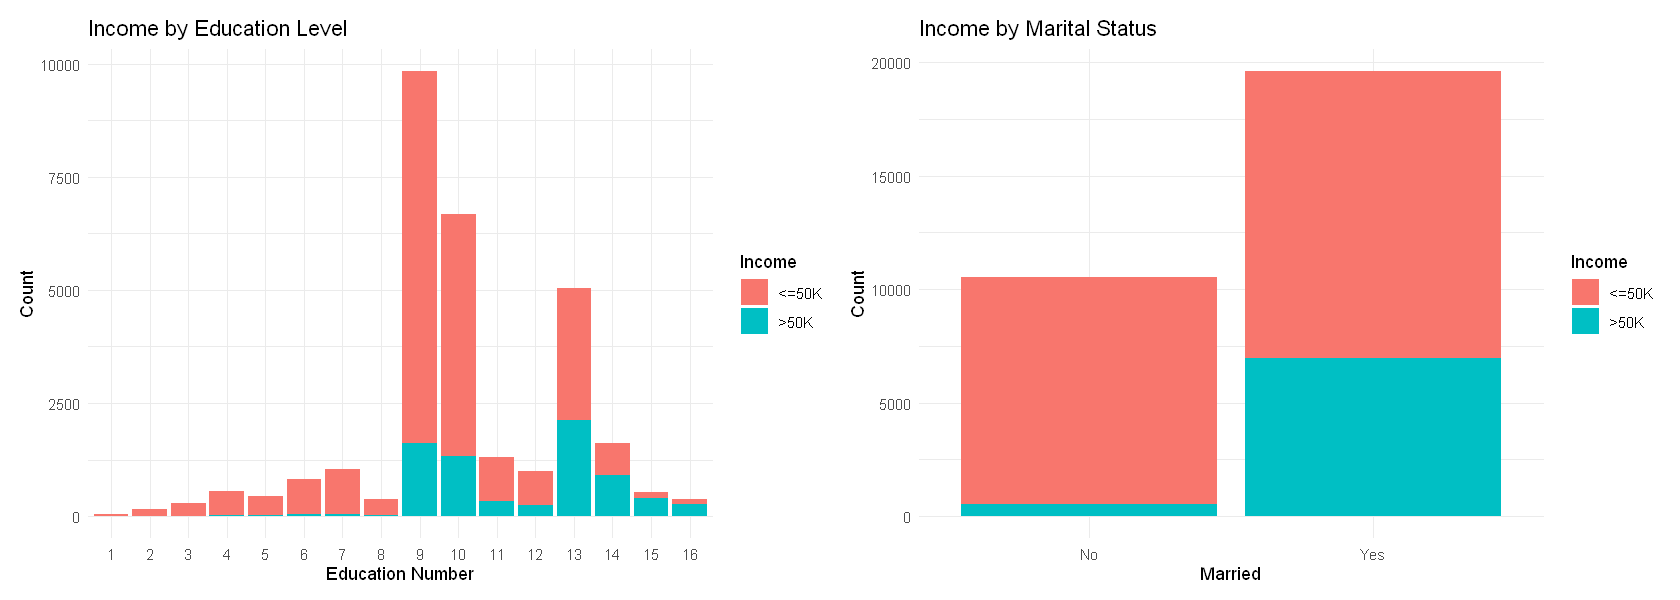

In [41]:
library(ggplot2)
library(dplyr)
library(patchwork)

# prepare plotting data
plot_df <- adult_processed |>
  mutate(
    income = factor(income, levels = c(0,1), labels = c("<=50K", ">50K")),
    married = factor(married, levels = c(0,1), labels = c("No", "Yes"))
  )

# ---- Plot 1 ----
p1 <- ggplot(plot_df, aes(x = factor(education_num), fill = income)) +
  geom_bar() +
  labs(
    title = "Income by Education Level",
    x = "Education Number",
    y = "Count",
    fill = "Income"
  ) +
  theme_minimal()

# ---- Plot 2 ----
p2 <- ggplot(plot_df, aes(x = married, fill = income)) +
  geom_bar() +
  labs(
    title = "Income by Marital Status",
    x = "Married",
    y = "Count",
    fill = "Income"
  ) +
  theme_minimal()

# ---- Side-by-side output ----
options(repr.plot.width = 14, repr.plot.height = 5)
p1 + p2

*Figure 2. Distribution of income by education level (left) and marital status (right) in the Adult dataset.*

In [42]:
install.packages("caret")

Warning message:
"package 'caret' is in use and will not be installed"


In [43]:
cm$table

          Reference
Prediction     0     1
         0 20801  4141
         1  1853  3367

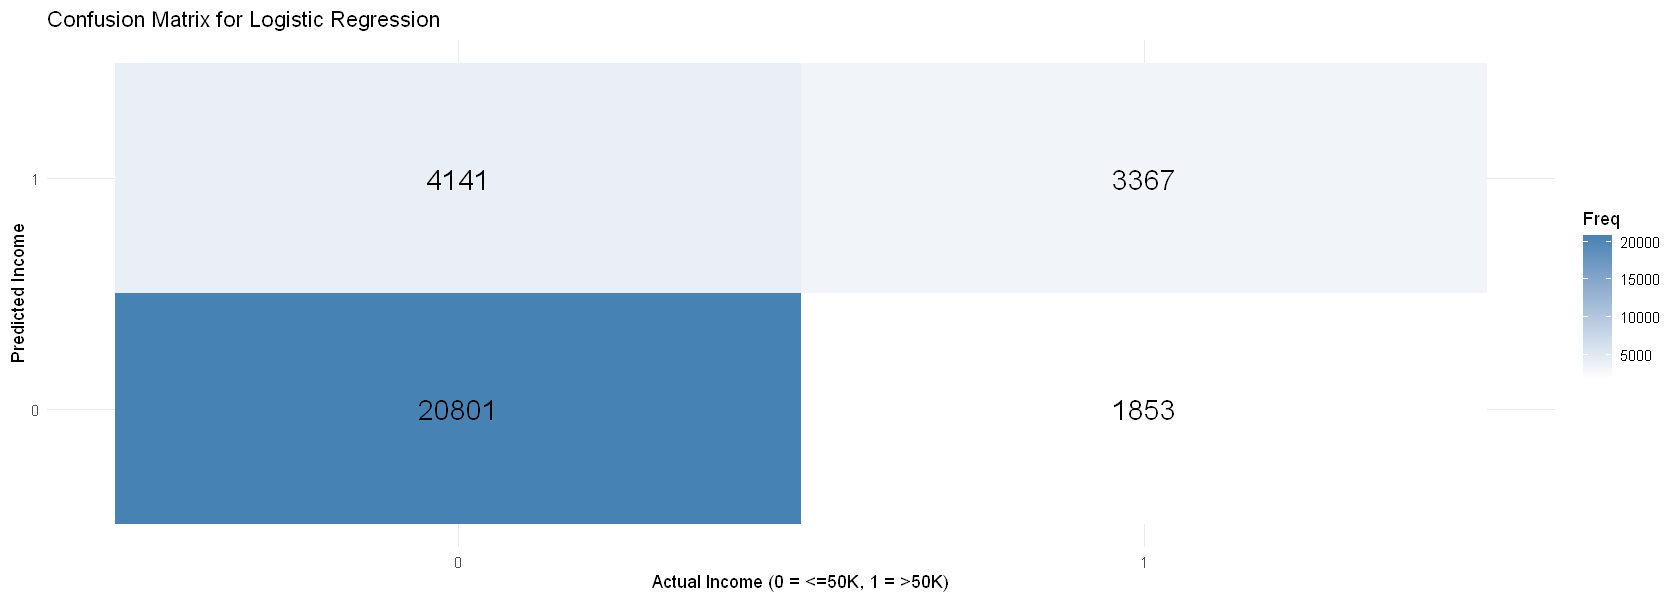

In [44]:
library(caret)
actual_f <- factor(adult_processed$income)
pred_f   <- factor(as.numeric(as.character(pred_class)))

cm <- confusionMatrix(pred_f, actual_f)
conf_df <- as.data.frame(cm$table)
names(conf_df) <- c("Actual", "Predicted", "Freq")

ggplot(conf_df, aes(x = Actual, y = Predicted, fill = Freq)) +
  geom_tile() +
  geom_text(aes(label = Freq), size = 6) +
  scale_fill_gradient(low = "white", high = "steelblue") +
  labs(
    title = "Confusion Matrix for Logistic Regression",
    x = "Actual Income (0 = <=50K, 1 = >50K)",
    y = "Predicted Income"
  ) +
  theme_minimal()

*Figure 3. Confusion matrix for logisic regression on Adult Dataset.*

Type 'citation("pROC")' for a citation.


Attaching package: 'pROC'


The following objects are masked from 'package:stats':

    cov, smooth, var


Setting levels: control = 0, case = 1

Setting direction: controls < cases



Area under the curve: 0.811

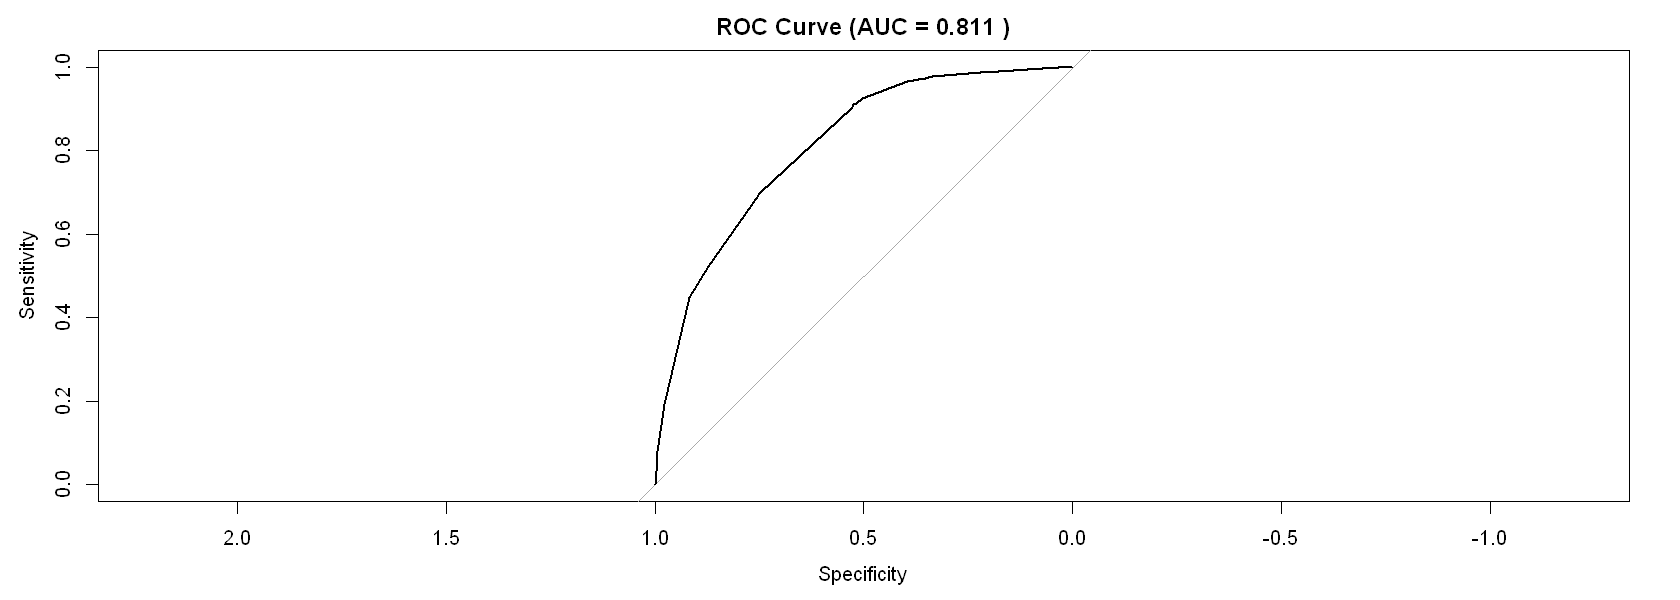

In [45]:
library(pROC)

roc_obj <- roc(adult_processed$income, pred_prob)

plot(roc_obj,
     main = paste("ROC Curve (AUC =",
                  round(auc(roc_obj), 3), ")"))

auc(roc_obj)

*Figure 4. ROC curve for logisic regression on Adult Dataset.*

### **Discussion**

We applied a logistic regression model to predict whether an individual earns `<= $50K` or `> $50K` annually. The model achieved an accuracy of approximately 80.13%, indicating strong predictive performance. Additionally, the Area Under the ROC Curve (AUC) is 0.811, suggesting that the model is effective at distinguishing between lower- and higher-income individuals.

From the exploratory visualizations, certain variables appear to contribute meaningfully to the model’s predictive performance:

- **Education level**: Higher education levels are associated with a greater proportion of individuals predicted as earning `> $50K`, suggesting that this variable is useful in distinguishing between income groups.
- **Marital status**: Married individuals are more frequently predicted as earning `> $50K`, indicating that this feature provides predictive signal for the model.

The confusion matrix shows that while overall performance is strong, the model performs better at predicting individuals in the `<= $50K` class than those in the `> $50K` class. Specifically, the model incorrectly classified 4,141 high-income individuals as low-income (false negatives), compared to 1,853 low-income individuals misclassified as high-income (false positives). This suggests that the model has lower sensitivity in detecting high-income earners.

This imbalance in performance is likely influenced by the class distribution in the dataset, where lower-income individuals are more prevalent. As a result, the model is better calibrated to predict the majority class.

#### Potential Implications

- **Predictive utility**: With an AUC of 0.811, the model demonstrates reasonable effectiveness for predicting income categories and could serve as a baseline for similar classification tasks.
- **Feature relevance**: Variables such as education level and marital status appear to provide useful predictive information and may be important inputs for future models.

#### Future Directions

- Would more complex models (e.g., random forests or gradient boosting) improve prediction, particularly for high-income individuals?
- How can class imbalance be addressed to improve sensitivity for the `> $50K` class?
- Does predictive performance vary across demographic subgroups such as gender, race, or age?

### **References**

Becker, Barry and Ronny Kohavi. "Adult." UCI Machine Learning Repository, 1996, https://doi.org/10.24432/C5XW20.

Cutright, Phillips. “Income and Family Events: Getting Married.” Journal of Marriage and the Family, vol. 32, no. 4, Nov. 1970, p. 628, https://doi.org/10.2307/350256. Accessed 3 Dec. 2019.

Rosenblum, Jordan, Lane Kenworthy, and Mikael Nygård. “Power and Inequality: Determinants of Income Inequality in Rich Capitalist Democracies, 1960 to 2019.” Socio‑Economic Review, vol. 23, no. 2, 2025, pp. 979–1012. Oxford University Press, https://doi.org/10.1093/ser/mwae071

STROBER, MYRA H. “Human Capital Theory: Implications for HR Managers.” Industrial Relations, vol. 29, no. 2, Mar. 1990, pp. 214–239.

Tan, Ziyang, et al. “Gender Income Inequality Within and Outside the State System in China, 2003–2021: An Age–Period–Cohort Analysis.” Sustainability (Switzerland), vol. 18, no. 1, 2026, article 130. MDPI, https://doi.org/10.3390/su18010130.